In [2]:
from gensim.models import KeyedVectors
import pickle
import matplotlib.pyplot as plt


In [5]:

kv = KeyedVectors.load("./model.model")

In [8]:
with open("./general_audience_speeches_tokenized.pkl", "rb") as f:
    sentences_A = pickle.load(f)

with open("./sentences_cbs.pkl", "rb") as f:
    sentences_B = pickle.load(f)

In [9]:

import numpy as np
from collections import Counter

def normalize_token_for_kv(t: str, kv):
    # return the first form that exists
    for cand in (t, t.lower(), t.title(), t.upper()):
        if cand in kv:
            return cand
    return None

def build_counts(sentences):
    return Counter(t.lower() for toks in sentences for t in toks)

countsA = build_counts(sentences_A)
countsB = build_counts(sentences_B)
countsAll = countsA + countsB
N = sum(countsAll.values())

def doc_vector(toks, kv, countsAll, N, a=1e-3):
    # SIF-ish weight: a/(a + p(w))
    vecs = []
    wts = []
    for t in toks:
        key = normalize_token_for_kv(t, kv)
        if not key:
            continue
        p = countsAll[t.lower()] / N
        wt = a / (a + p)
        vecs.append(kv[key])
        wts.append(wt)

    if not vecs:
        return np.zeros(kv.vector_size, dtype=np.float32)

    vecs = np.vstack(vecs)
    wts = np.array(wts, dtype=np.float32)
    v = (vecs * wts[:, None]).sum(axis=0) / (wts.sum() + 1e-12)
    return v.astype(np.float32)

docA = np.vstack([doc_vector(toks, kv, countsAll, N) for toks in sentences_A])
docB = np.vstack([doc_vector(toks, kv, countsAll, N) for toks in sentences_B])

# cosine normalize
def l2norm(M):
    norms = np.linalg.norm(M, axis=1, keepdims=True) + 1e-12
    return M / norms

docA_n = l2norm(docA)
docB_n = l2norm(docB)

In [10]:
centA = docA_n.mean(axis=0); centA /= (np.linalg.norm(centA) + 1e-12)
centB = docB_n.mean(axis=0); centB /= (np.linalg.norm(centB) + 1e-12)

simA_to_B = docA_n @ centB
simB_to_A = docB_n @ centA

quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]
qA = np.quantile(simA_to_B, quantiles)
qB = np.quantile(simB_to_A, quantiles)

qA, qB

(array([0.81922084, 0.85582936, 0.8758037 , 0.9102453 , 0.9162403 ],
       dtype=float32),
 array([0.42373884, 0.8520249 , 0.8989011 , 0.9344125 , 0.95795727],
       dtype=float32))

In [11]:
B_sample = docB_n[np.random.choice(len(docB_n), size=len(docA_n), replace=False)]

centB_sample = B_sample.mean(axis=0)
centB_sample /= np.linalg.norm(centB_sample)

simA_balanced = docA_n @ centB_sample
np.quantile(simA_balanced, [0.1,0.25,0.5,0.75,0.9])

array([0.8191377 , 0.8501616 , 0.87118363, 0.90535104, 0.91212416],
      dtype=float32)

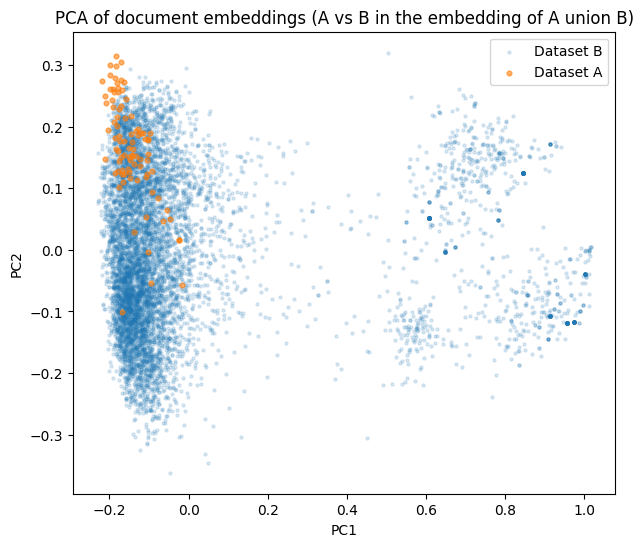

In [12]:
from sklearn.decomposition import PCA

X = np.vstack([docA_n, docB_n])
pca = PCA(n_components=2, random_state=0)
XY = pca.fit_transform(X)

XY_A = XY[:len(docA_n)]
XY_B = XY[len(docA_n):]
plt.figure(figsize=(7,6))
plt.scatter(XY_B[:,0], XY_B[:,1], s=5, alpha=0.15, label="Dataset B")
plt.scatter(XY_A[:,0], XY_A[:,1], s=12, alpha=0.6, label="Dataset A")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of document embeddings (A vs B in the embedding of A union B)")
plt.show()

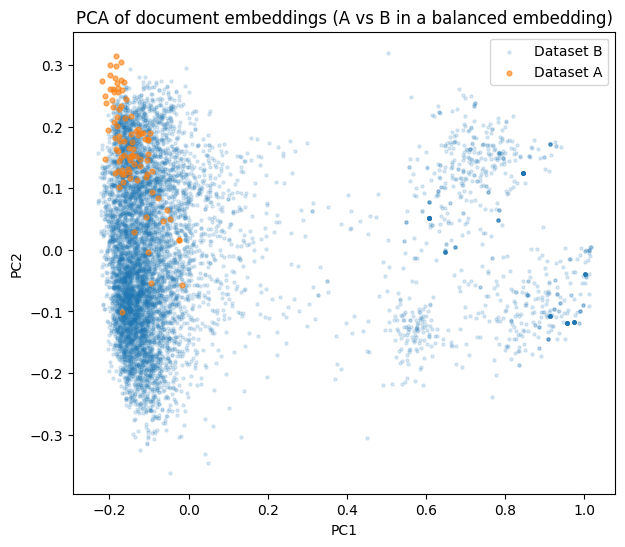

In [13]:
B_sample = docB_n[np.random.choice(len(docB_n), len(docA_n), replace=False)]
X_bal = np.vstack([docA_n, B_sample])

pca.fit_transform(X_bal)

XY_A = XY[:len(docA_n)]
XY_B = XY[len(docA_n):]
plt.figure(figsize=(7,6))
plt.scatter(XY_B[:,0], XY_B[:,1], s=5, alpha=0.15, label="Dataset B")
plt.scatter(XY_A[:,0], XY_A[:,1], s=12, alpha=0.6, label="Dataset A")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of document embeddings (A vs B in a balanced embedding)")
plt.show()



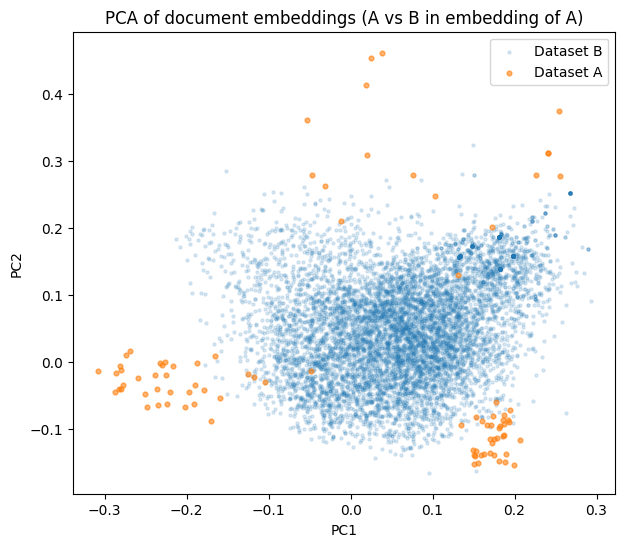

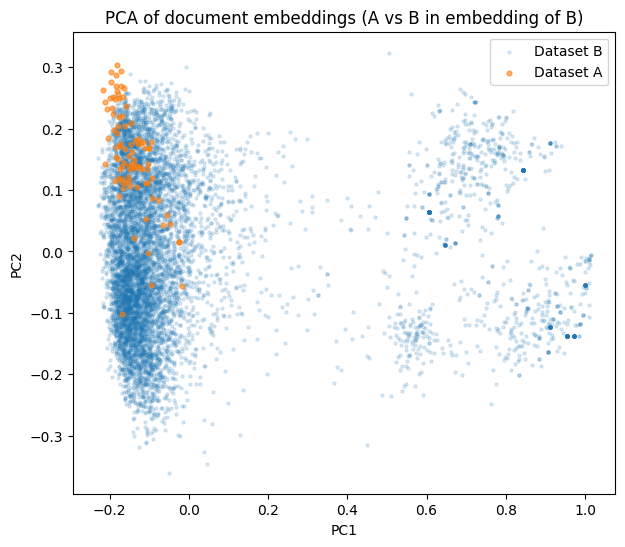

In [14]:
pca = PCA(n_components=2, random_state=0)
pca.fit(docA_n)

XY_A = pca.transform(docA_n)
XY_B = pca.transform(docB_n)

plt.figure(figsize=(7,6))
plt.scatter(XY_B[:,0], XY_B[:,1], s=5, alpha=0.15, label="Dataset B")
plt.scatter(XY_A[:,0], XY_A[:,1], s=12, alpha=0.6, label="Dataset A")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of document embeddings (A vs B in embedding of A)")
plt.show()

pca = PCA(n_components=2, random_state=0)
pca.fit(docB_n)

XY_A = pca.transform(docA_n)
XY_B = pca.transform(docB_n)

plt.figure(figsize=(7,6))
plt.scatter(XY_B[:,0], XY_B[:,1], s=5, alpha=0.15, label="Dataset B")
plt.scatter(XY_A[:,0], XY_A[:,1], s=12, alpha=0.6, label="Dataset A")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.title("PCA of document embeddings (A vs B in embedding of B)") #not very interesting tbh
plt.show()





In [15]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

nn = NearestNeighbors(n_neighbors=1, metric="cosine")
nn.fit(docB_n)

dist, idx = nn.kneighbors(docA_n)
# cosine distance = 1 - cosine similarity
sim_A_to_B = 1 - dist.ravel()


k = 20  # how many are selected
far_idx = np.argsort(sim_A_to_B)[:k]

res = dict()
for idx in far_idx:
    res[idx] = " ".join(sentences_A[idx])

In [16]:
res

{np.int64(81): 'the fed has been assigned two goals for monetary policy maximum employment and stable prices we remain committed to supporting maximum employment bringing inflation sustainably to our goal and keeping longer term inflation expectations well anchored our success in delivering on these goals matters to all americans',
 np.int64(79): 'the fed has been assigned two goals for monetary policy maximum employment and stable prices we remain committed to supporting maximum employment bringing inflation sustainably to our percent goal and keeping longer run inflation expectations well anchored our success in delivering on these goals matters to all americans',
 np.int64(83): 'the fed has been assigned two goals for monetary policy maximum employment and stable prices we remain committed to bringing inflation back down to our percent goal and to keeping the longer term inflation expectations well anchored restoring price stability is essential to achieving maximum employment and s